# Notebook 2 - Part A

# Dataset Organization

This notebook prepares the RICE2 dataset for training.

Pipeline

RICE2

↓

Cloud Images

↓

Clear Images

↓

Cloud Masks

↓

CloudRemovalAI Dataset

In [23]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import glob
import shutil
import pandas as pd
from tqdm import tqdm

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [24]:
# ==========================================================
# PROJECT PATHS
# ==========================================================

PROJECT_PATH = "/content/drive/MyDrive/CloudRemovalAI"

DATASET_PATH = os.path.join(PROJECT_PATH, "dataset")

RAW_PATH = os.path.join(DATASET_PATH, "raw")

CLOUDY_PATH = os.path.join(RAW_PATH, "cloudy")

CLEAR_PATH = os.path.join(RAW_PATH, "clear")

MASK_PATH = os.path.join(RAW_PATH, "mask")

EXTRACT_PATH = os.path.join(DATASET_PATH, "extracted")

print(PROJECT_PATH)

/content/drive/MyDrive/CloudRemovalAI


In [25]:
# ==========================================================
# CREATE REQUIRED FOLDERS
# ==========================================================

folders = [

    CLOUDY_PATH,

    CLEAR_PATH,

    MASK_PATH

]

for folder in folders:

    os.makedirs(folder, exist_ok=True)

print("✅ Folder Structure Ready")

✅ Folder Structure Ready


In [26]:
# ==========================================================
# RICE2 PATHS
# ==========================================================

RICE2_PATH = os.path.join(EXTRACT_PATH, "RICE", "RICE2")

RICE2_CLOUD = os.path.join(RICE2_PATH, "cloud")

RICE2_LABEL = os.path.join(RICE2_PATH, "label")

RICE2_MASK = os.path.join(RICE2_PATH, "mask")

print(RICE2_PATH)

/content/drive/MyDrive/CloudRemovalAI/dataset/extracted/RICE/RICE2


In [27]:
# ==========================================================
# VERIFY DATASET
# ==========================================================

paths = [

    RICE2_CLOUD,

    RICE2_LABEL,

    RICE2_MASK

]

print("="*60)

for p in paths:

    if os.path.exists(p):

        print("✅",p)

    else:

        print("❌",p)

print("="*60)

✅ /content/drive/MyDrive/CloudRemovalAI/dataset/extracted/RICE/RICE2/cloud
✅ /content/drive/MyDrive/CloudRemovalAI/dataset/extracted/RICE/RICE2/label
✅ /content/drive/MyDrive/CloudRemovalAI/dataset/extracted/RICE/RICE2/mask


In [28]:
# ==========================================================
# REMOVE OLD DATA
# ==========================================================

folders = [

    CLOUDY_PATH,

    CLEAR_PATH,

    MASK_PATH

]

for folder in folders:

    files = glob.glob(os.path.join(folder,"*"))

    for file in files:

        os.remove(file)

print("✅ Previous Dataset Removed")

✅ Previous Dataset Removed


In [29]:
# ==========================================================
# READ IMAGE LIST
# ==========================================================

cloud_images = sorted(

    glob.glob(

        os.path.join(RICE2_CLOUD,"*.png")

    )

)

clear_images = sorted(

    glob.glob(

        os.path.join(RICE2_LABEL,"*.png")

    )

)

mask_images = sorted(

    glob.glob(

        os.path.join(RICE2_MASK,"*.png")

    )

)

print("Cloud :",len(cloud_images))

print("Clear :",len(clear_images))

print("Mask :",len(mask_images))

Cloud : 736
Clear : 736
Mask : 736


In [30]:
# ==========================================================
# COPY CLOUD IMAGES
# ==========================================================

print("Copying Cloud Images...")

for image in tqdm(cloud_images):

    shutil.copy(

        image,

        CLOUDY_PATH

    )

print("Done")

Copying Cloud Images...


100%|██████████| 736/736 [00:17<00:00, 42.27it/s]

Done


In [31]:
# ==========================================================
# COPY CLEAR IMAGES
# ==========================================================

print("Copying Clear Images...")

for image in tqdm(clear_images):

    shutil.copy(

        image,

        CLEAR_PATH

    )

print("Done")

Copying Clear Images...


100%|██████████| 736/736 [00:14<00:00, 52.35it/s]

Done


In [32]:
# ==========================================================
# COPY MASK IMAGES
# ==========================================================

print("Copying Mask Images...")

for image in tqdm(mask_images):

    shutil.copy(

        image,

        MASK_PATH

    )

print("Done")

Copying Mask Images...


100%|██████████| 736/736 [00:12<00:00, 59.12it/s]

Done


In [34]:
# ==========================================================
# VERIFY COPIED DATA
# ==========================================================

cloudy = glob.glob(

    os.path.join(CLOUDY_PATH,"*.png")

)

clear = glob.glob(

    os.path.join(CLEAR_PATH,"*.png")

)

mask = glob.glob(

    os.path.join(MASK_PATH,"*.png")

)

print("="*60)

print("Cloud Images :",len(cloudy))

print("Clear Images :",len(clear))

print("Mask Images :",len(mask))

print("="*60)

Cloud Images : 736
Clear Images : 736
Mask Images : 736


In [35]:
# ==========================================================
# VERIFY IMAGE PAIRS
# ==========================================================

matched = 0

for c,l,m in zip(

    sorted(cloudy),

    sorted(clear),

    sorted(mask)

):

    c_name = os.path.basename(c)

    l_name = os.path.basename(l)

    m_name = os.path.basename(m)

    if c_name==l_name==m_name:

        matched +=1

print()

print("Matched Images :",matched)


Matched Images : 736


In [36]:
# ==========================================================
# CREATE METADATA
# ==========================================================

data=[]

for c,l,m in zip(

    sorted(cloudy),

    sorted(clear),

    sorted(mask)

):

    data.append({

        "cloud":c,

        "clear":l,

        "mask":m

    })

metadata = pd.DataFrame(data)

metadata.head()

,cloud,clear,mask
0,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
1,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
2,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
3,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
4,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...


In [37]:
# ==========================================================
# SAVE METADATA
# ==========================================================

metadata_path = os.path.join(

    DATASET_PATH,

    "metadata.csv"

)

metadata.to_csv(

    metadata_path,

    index=False

)

print(metadata_path)

/content/drive/MyDrive/CloudRemovalAI/dataset/metadata.csv


In [38]:
# ==========================================================
# SUMMARY
# ==========================================================

print("="*70)

print("NOTEBOOK 2 PART A COMPLETED")

print()

print("Dataset : RICE2")

print()

print("Cloud Images :",len(cloudy))

print("Clear Images :",len(clear))

print("Mask Images :",len(mask))

print()

print("Metadata File Saved")

print(metadata_path)

print("="*70)

NOTEBOOK 2 PART A COMPLETED

Dataset : RICE2

Cloud Images : 736
Clear Images : 736
Mask Images : 736

Metadata File Saved
/content/drive/MyDrive/CloudRemovalAI/dataset/metadata.csv


# Notebook 2 - Part B

## Dataset Exploration & Visualization

This notebook analyzes the RICE2 dataset before preprocessing and training.

Contents

- Load metadata
- Verify dataset
- Display image pairs
- Display masks
- Dataset statistics
- Image properties
- RGB analysis
- Brightness analysis

In [40]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [41]:
# ==========================================================
# LOAD METADATA
# ==========================================================

PROJECT_PATH="/content/drive/MyDrive/CloudRemovalAI"

metadata_path=os.path.join(
    PROJECT_PATH,
    "dataset",
    "metadata.csv"
)

metadata=pd.read_csv(metadata_path)

print("Total Samples :",len(metadata))

metadata.head()

Total Samples : 736


,cloud,clear,mask
0,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
1,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
2,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
3,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
4,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...


In [42]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cloud   736 non-null    object
 1   clear   736 non-null    object
 2   mask    736 non-null    object
dtypes: object(3)
memory usage: 17.4+ KB


In [43]:
# ==========================================================
# CHECK MISSING VALUES
# ==========================================================

metadata.isnull().sum()

,0
cloud,0
clear,0
mask,0


In [44]:
# ==========================================================
# RANDOM SAMPLE
# ==========================================================

sample=metadata.sample(5)

sample

,cloud,clear,mask
482,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
433,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
330,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
314,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
687,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...


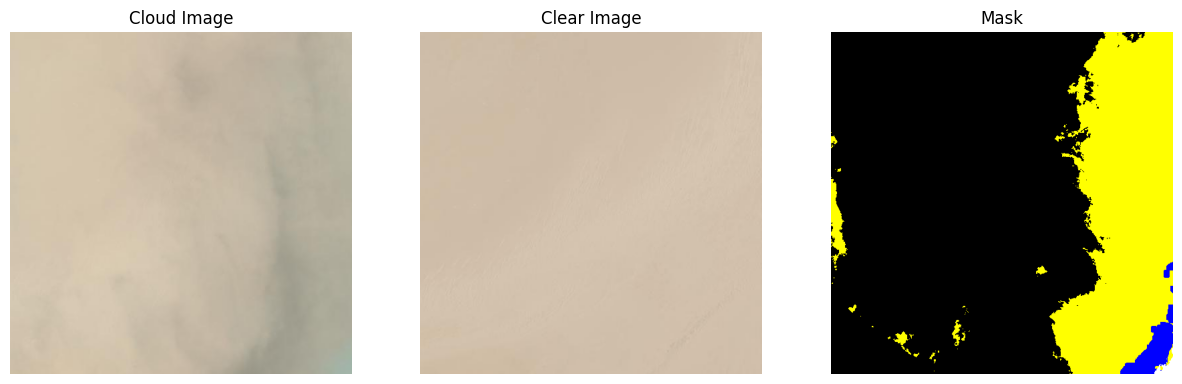

In [45]:
# ==========================================================
# DISPLAY ONE SAMPLE
# ==========================================================

index=random.randint(0,len(metadata)-1)

cloud=Image.open(metadata.iloc[index]["cloud"])

clear=Image.open(metadata.iloc[index]["clear"])

mask=Image.open(metadata.iloc[index]["mask"])

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cloud)
plt.title("Cloud Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(clear)
plt.title("Clear Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask,cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

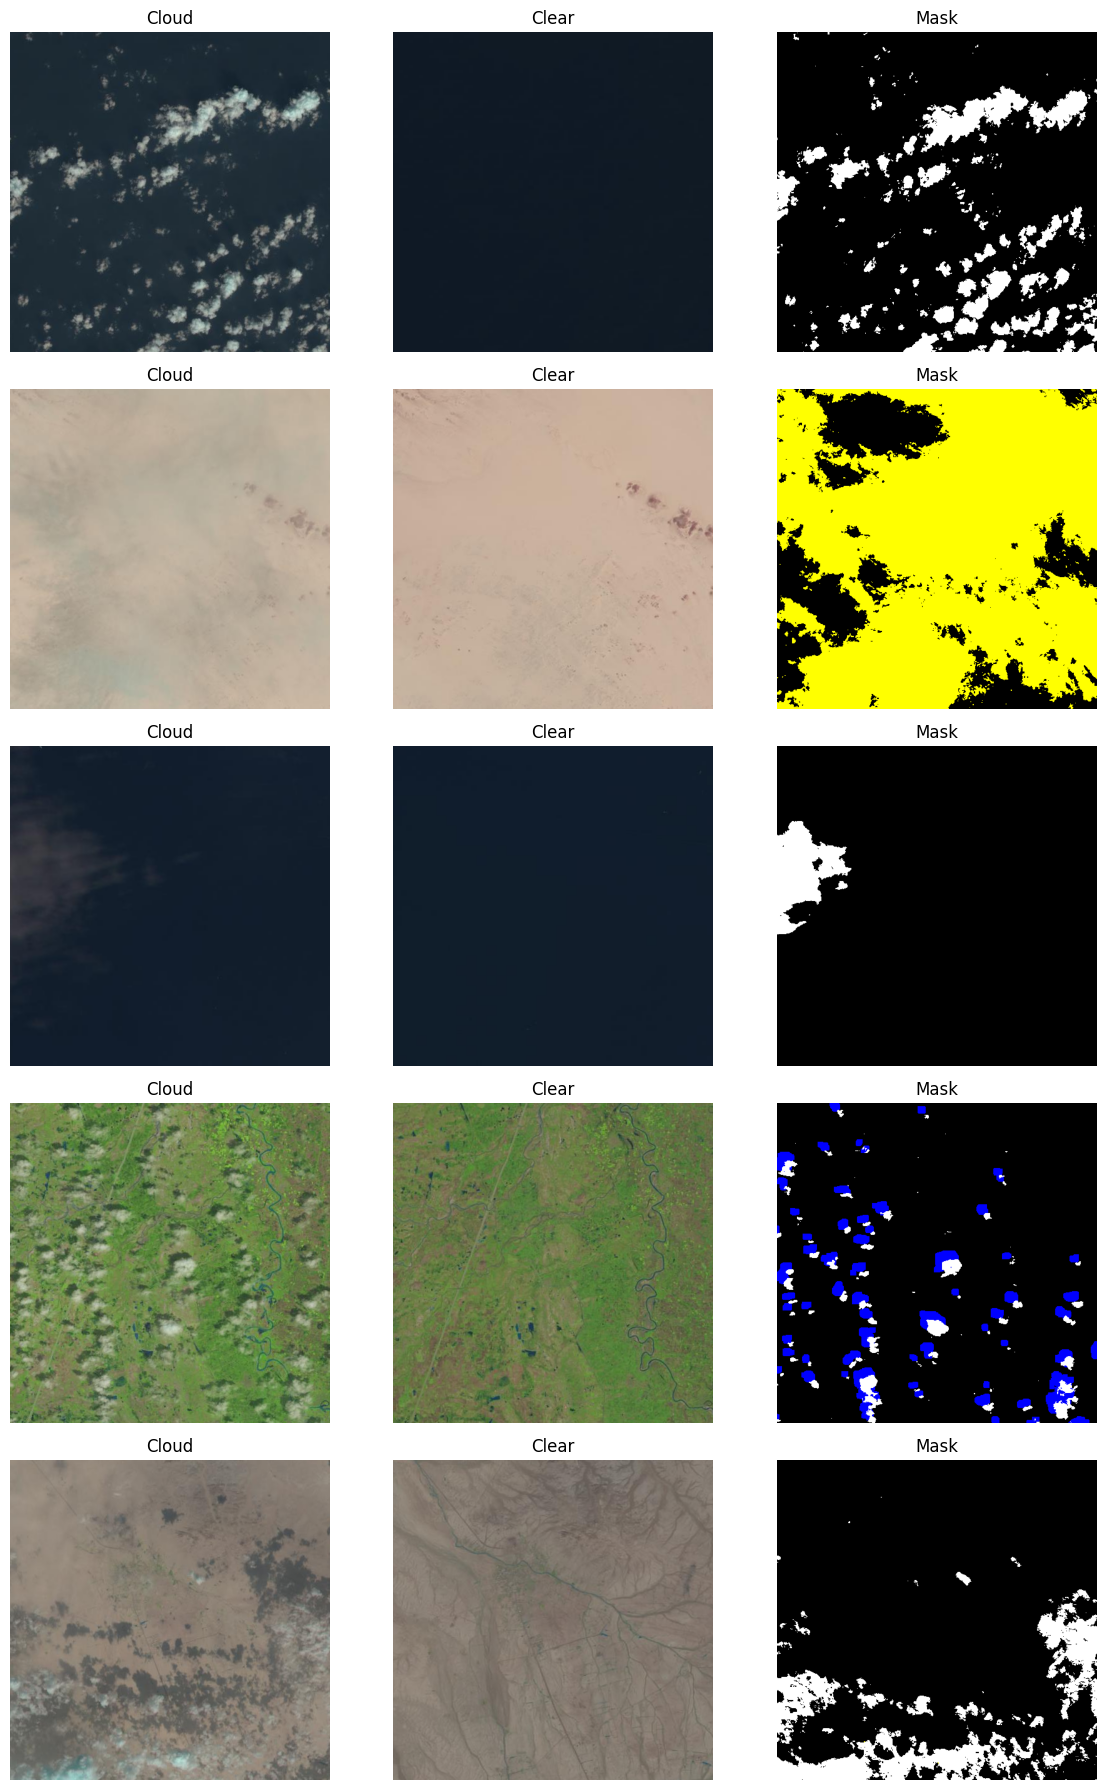

In [46]:
# ==========================================================
# DISPLAY FIVE RANDOM IMAGES
# ==========================================================

rows=5

fig,ax=plt.subplots(rows,3,figsize=(12,18))

indices=random.sample(range(len(metadata)),rows)

for i,idx in enumerate(indices):

    cloud=np.array(Image.open(metadata.iloc[idx]["cloud"]))

    clear=np.array(Image.open(metadata.iloc[idx]["clear"]))

    mask=np.array(Image.open(metadata.iloc[idx]["mask"]))

    ax[i,0].imshow(cloud)
    ax[i,0].set_title("Cloud")
    ax[i,0].axis("off")

    ax[i,1].imshow(clear)
    ax[i,1].set_title("Clear")
    ax[i,1].axis("off")

    ax[i,2].imshow(mask,cmap="gray")
    ax[i,2].set_title("Mask")
    ax[i,2].axis("off")

plt.tight_layout()

plt.show()

In [47]:
# ==========================================================
# IMAGE SIZE ANALYSIS
# ==========================================================

sizes=[]

for path in metadata["cloud"]:

    img=Image.open(path)

    sizes.append(img.size)

sizes=pd.DataFrame(
    sizes,
    columns=["Width","Height"]
)

sizes.describe()

,Width,Height
count,736.0,736.0
mean,512.0,512.0
std,0.0,0.0
min,512.0,512.0
25%,512.0,512.0
50%,512.0,512.0
75%,512.0,512.0
max,512.0,512.0


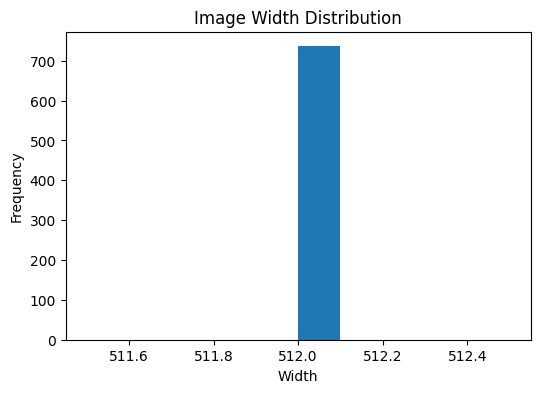

In [48]:
# ==========================================================
# IMAGE SIZE HISTOGRAM
# ==========================================================

plt.figure(figsize=(6,4))

plt.hist(sizes["Width"])

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

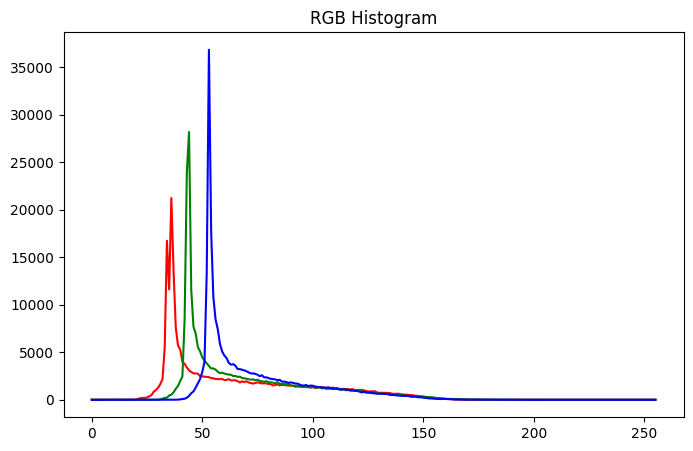

In [49]:
# ==========================================================
# RGB HISTOGRAM
# ==========================================================

img=np.array(
    Image.open(
        metadata.iloc[0]["cloud"]
    )
)

colors=("r","g","b")

plt.figure(figsize=(8,5))

for i,color in enumerate(colors):

    hist=np.histogram(
        img[:,:,i],
        bins=256,
        range=(0,255)
    )[0]

    plt.plot(hist,color=color)

plt.title("RGB Histogram")

plt.show()

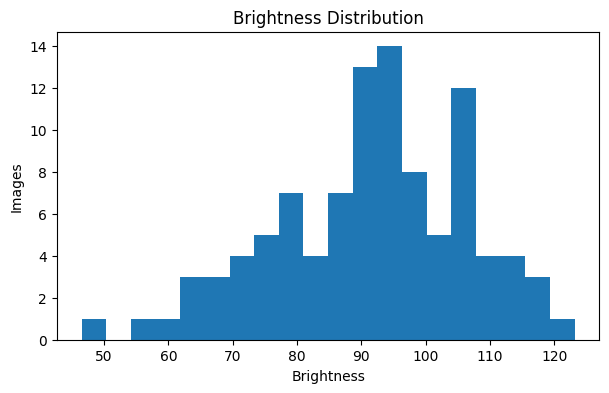

In [50]:
# ==========================================================
# BRIGHTNESS DISTRIBUTION
# ==========================================================

brightness=[]

for path in metadata["cloud"][:100]:

    img=np.array(Image.open(path))

    brightness.append(img.mean())

plt.figure(figsize=(7,4))

plt.hist(brightness,bins=20)

plt.title("Brightness Distribution")

plt.xlabel("Brightness")

plt.ylabel("Images")

plt.show()

In [51]:
# ==========================================================
# DATASET SUMMARY
# ==========================================================

print("="*60)

print("Total Images :",len(metadata))

print("Cloud Images :",len(metadata["cloud"]))

print("Clear Images :",len(metadata["clear"]))

print("Mask Images :",len(metadata["mask"]))

print()

print("Image Resolution : 512 x 512")

print()

print("Dataset Ready for Preprocessing")

print("="*60)

Total Images : 736
Cloud Images : 736
Clear Images : 736
Mask Images : 736

Image Resolution : 512 x 512

Dataset Ready for Preprocessing


In [52]:
# ==========================================================
# NOTEBOOK COMPLETED
# ==========================================================

print("="*70)

print("NOTEBOOK 2 PART B COMPLETED")

print()

print("Dataset Verified")

print("Visualization Completed")

print("Statistics Generated")

print("Ready for Preprocessing")

print("="*70)

NOTEBOOK 2 PART B COMPLETED

Dataset Verified
Visualization Completed
Statistics Generated
Ready for Preprocessing


# Notebook 2 - Part C

## Dataset Preprocessing

Pipeline

Raw Images

↓

Resize

↓

Normalize

↓

Augmentation

↓

Processed Dataset

↓

Ready for Training

In [53]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [54]:
# ==========================================================
# PROJECT PATHS
# ==========================================================

PROJECT_PATH="/content/drive/MyDrive/CloudRemovalAI"

RAW_PATH=os.path.join(PROJECT_PATH,"dataset/raw")

PROCESSED_PATH=os.path.join(PROJECT_PATH,"dataset/processed")

CLOUD_RAW=os.path.join(RAW_PATH,"cloudy")
CLEAR_RAW=os.path.join(RAW_PATH,"clear")
MASK_RAW=os.path.join(RAW_PATH,"mask")

CLOUD_OUT=os.path.join(PROCESSED_PATH,"cloudy")
CLEAR_OUT=os.path.join(PROCESSED_PATH,"clear")
MASK_OUT=os.path.join(PROCESSED_PATH,"mask")

print("Paths Ready")

Paths Ready


In [55]:
# ==========================================================
# CREATE OUTPUT FOLDERS
# ==========================================================

folders=[
    CLOUD_OUT,
    CLEAR_OUT,
    MASK_OUT
]

for folder in folders:
    os.makedirs(folder,exist_ok=True)

print("Processed Folder Ready")

Processed Folder Ready


In [56]:
# ==========================================================
# READ DATASET
# ==========================================================

import glob

cloud_images=sorted(glob.glob(os.path.join(CLOUD_RAW,"*.png")))
clear_images=sorted(glob.glob(os.path.join(CLEAR_RAW,"*.png")))
mask_images=sorted(glob.glob(os.path.join(MASK_RAW,"*.png")))

print("Cloud :",len(cloud_images))
print("Clear :",len(clear_images))
print("Mask :",len(mask_images))

Cloud : 736
Clear : 736
Mask : 736


In [57]:
# ==========================================================
# IMAGE RESIZE FUNCTION
# ==========================================================

IMAGE_SIZE=(512,512)

def resize_image(path):

    img=cv2.imread(path)

    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    img=cv2.resize(img,IMAGE_SIZE)

    return img

In [58]:
# ==========================================================
# NORMALIZATION
# ==========================================================

def normalize(img):

    img=img.astype(np.float32)

    img=img/255.0

    return img

In [59]:
# ==========================================================
# SAVE IMAGE
# ==========================================================

def save_image(image,path):

    image=(image*255).astype(np.uint8)

    image=cv2.cvtColor(image,cv2.COLOR_RGB2BGR)

    cv2.imwrite(path,image)

In [60]:
# ==========================================================
# PROCESS CLOUD IMAGES
# ==========================================================

for img_path in tqdm(cloud_images):

    img=resize_image(img_path)

    img=normalize(img)

    filename=os.path.basename(img_path)

    save_image(
        img,
        os.path.join(CLOUD_OUT,filename)
    )

print("Cloud Images Processed")

100%|██████████| 736/736 [00:43<00:00, 17.00it/s]

Cloud Images Processed


In [61]:
# ==========================================================
# PROCESS CLEAR IMAGES
# ==========================================================

for img_path in tqdm(clear_images):

    img=resize_image(img_path)

    img=normalize(img)

    filename=os.path.basename(img_path)

    save_image(
        img,
        os.path.join(CLEAR_OUT,filename)
    )

print("Clear Images Processed")

100%|██████████| 736/736 [00:34<00:00, 21.12it/s]

Clear Images Processed


In [62]:
# ==========================================================
# PROCESS MASKS
# ==========================================================

for img_path in tqdm(mask_images):

    img=cv2.imread(img_path,0)

    img=cv2.resize(img,IMAGE_SIZE)

    cv2.imwrite(
        os.path.join(
            MASK_OUT,
            os.path.basename(img_path)
        ),
        img
    )

print("Masks Processed")

100%|██████████| 736/736 [00:17<00:00, 42.26it/s]

Masks Processed


In [63]:
# ==========================================================
# HORIZONTAL FLIP
# ==========================================================

def horizontal_flip(img):

    return cv2.flip(img,1)

In [64]:
# ==========================================================
# VERTICAL FLIP
# ==========================================================

def vertical_flip(img):

    return cv2.flip(img,0)

In [65]:
# ==========================================================
# ROTATION
# ==========================================================

def rotate(img):

    return cv2.rotate(
        img,
        cv2.ROTATE_90_CLOCKWISE
    )

In [66]:
# ==========================================================
# VERIFY DATASET
# ==========================================================

processed_cloud=len(glob.glob(os.path.join(CLOUD_OUT,"*.png")))
processed_clear=len(glob.glob(os.path.join(CLEAR_OUT,"*.png")))
processed_mask=len(glob.glob(os.path.join(MASK_OUT,"*.png")))

print("="*60)

print("Processed Cloud :",processed_cloud)

print("Processed Clear :",processed_clear)

print("Processed Mask :",processed_mask)

print("="*60)

Processed Cloud : 736
Processed Clear : 736
Processed Mask : 736


In [67]:
# ==========================================================
# CREATE METADATA
# ==========================================================

data=[]

for filename in sorted(os.listdir(CLOUD_OUT)):

    data.append({

        "cloud":os.path.join(CLOUD_OUT,filename),

        "clear":os.path.join(CLEAR_OUT,filename),

        "mask":os.path.join(MASK_OUT,filename)

    })

metadata=pd.DataFrame(data)

metadata.head()

,cloud,clear,mask
0,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
1,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
2,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
3,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
4,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...


In [68]:
# ==========================================================
# SAVE METADATA
# ==========================================================

metadata_path=os.path.join(
    PROJECT_PATH,
    "dataset",
    "processed_metadata.csv"
)

metadata.to_csv(
    metadata_path,
    index=False
)

print(metadata_path)

/content/drive/MyDrive/CloudRemovalAI/dataset/processed_metadata.csv


In [69]:
# ==========================================================
# SUMMARY
# ==========================================================

print("="*70)

print("NOTEBOOK 2 PART C COMPLETED")

print()

print("Cloud Images :",processed_cloud)

print("Clear Images :",processed_clear)

print("Mask Images :",processed_mask)

print()

print("Processed Dataset Ready")

print()

print(metadata_path)

print("="*70)

NOTEBOOK 2 PART C COMPLETED

Cloud Images : 736
Clear Images : 736
Mask Images : 736

Processed Dataset Ready

/content/drive/MyDrive/CloudRemovalAI/dataset/processed_metadata.csv


# Notebook 2 - Part D

## PyTorch Dataset & DataLoader

Pipeline

Metadata

↓

Train Validation Test Split

↓

Custom Dataset

↓

Transforms

↓

DataLoader

↓

Ready for Training

In [70]:
# Uncomment if torchvision is missing

!pip install torchvision

In [71]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import random
import pandas as pd
import numpy as np

from PIL import Image

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [72]:
# ==========================================================
# LOAD METADATA
# ==========================================================

PROJECT_PATH="/content/drive/MyDrive/CloudRemovalAI"

metadata_path=os.path.join(
    PROJECT_PATH,
    "dataset",
    "metadata.csv"
)

metadata=pd.read_csv(metadata_path)

print(metadata.shape)

metadata.head()

(736, 3)


,cloud,clear,mask
0,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
1,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
2,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
3,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...
4,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...,/content/drive/MyDrive/CloudRemovalAI/dataset/...


In [73]:
# ==========================================================
# TRAIN VALIDATION TEST SPLIT
# ==========================================================

train_df,temp_df=train_test_split(

    metadata,

    test_size=0.20,

    random_state=42,

    shuffle=True

)

valid_df,test_df=train_test_split(

    temp_df,

    test_size=0.50,

    random_state=42

)

print("Train :",len(train_df))

print("Validation :",len(valid_df))

print("Test :",len(test_df))

Train : 588
Validation : 74
Test : 74


In [74]:
# ==========================================================
# SAVE SPLITS
# ==========================================================

split_path=os.path.join(PROJECT_PATH,"dataset","splits")

os.makedirs(split_path,exist_ok=True)

train_df.to_csv(os.path.join(split_path,"train.csv"),index=False)

valid_df.to_csv(os.path.join(split_path,"validation.csv"),index=False)

test_df.to_csv(os.path.join(split_path,"test.csv"),index=False)

print("CSV Files Saved")

CSV Files Saved


In [75]:
# ==========================================================
# IMAGE TRANSFORM
# ==========================================================

transform=transforms.Compose([

    transforms.Resize((512,512)),

    transforms.ToTensor()

])

In [76]:
# ==========================================================
# CUSTOM DATASET
# ==========================================================

class CloudRemovalDataset(Dataset):

    def __init__(self,dataframe,transform=None):

        self.df=dataframe

        self.transform=transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self,index):

        cloud=Image.open(
            self.df.iloc[index]["cloud"]
        ).convert("RGB")

        clear=Image.open(
            self.df.iloc[index]["clear"]
        ).convert("RGB")

        mask=Image.open(
            self.df.iloc[index]["mask"]
        ).convert("L")

        if self.transform:

            cloud=self.transform(cloud)

            clear=self.transform(clear)

            mask=self.transform(mask)

        return{

            "cloud":cloud,

            "clear":clear,

            "mask":mask

        }

In [77]:
# ==========================================================
# DATASET OBJECTS
# ==========================================================

train_dataset=CloudRemovalDataset(

    train_df,

    transform

)

valid_dataset=CloudRemovalDataset(

    valid_df,

    transform

)

test_dataset=CloudRemovalDataset(

    test_df,

    transform

)

print(len(train_dataset))

588


In [78]:
# ==========================================================
# DATALOADERS
# ==========================================================

BATCH_SIZE=8

train_loader=DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2

)

valid_loader=DataLoader(

    valid_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2

)

test_loader=DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2

)

print("DataLoaders Ready")

DataLoaders Ready


In [79]:
# ==========================================================
# VERIFY BATCH
# ==========================================================

batch=next(iter(train_loader))

print(batch["cloud"].shape)

print(batch["clear"].shape)

print(batch["mask"].shape)

torch.Size([8, 3, 512, 512])
torch.Size([8, 3, 512, 512])
torch.Size([8, 1, 512, 512])


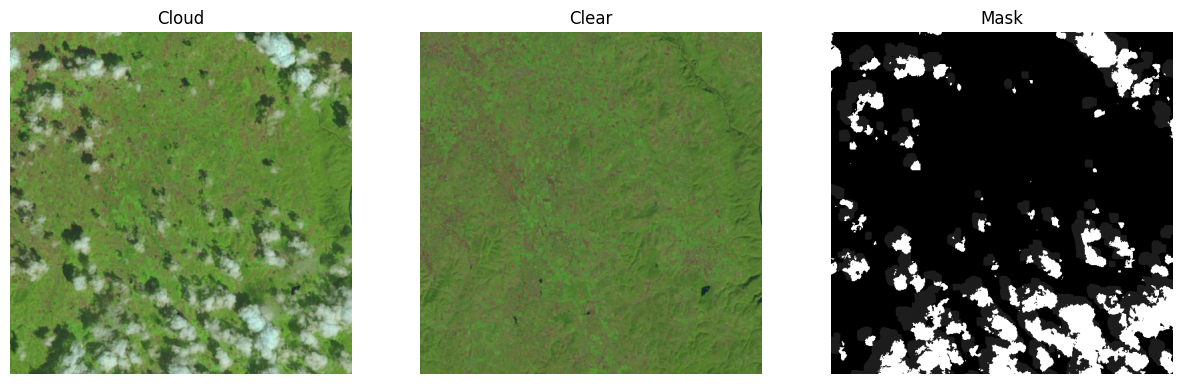

In [80]:
import matplotlib.pyplot as plt

sample=batch

cloud=sample["cloud"][0].permute(1,2,0)

clear=sample["clear"][0].permute(1,2,0)

mask=sample["mask"][0][0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(cloud)

plt.title("Cloud")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(clear)

plt.title("Clear")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(mask,cmap="gray")

plt.title("Mask")

plt.axis("off")

plt.show()

In [81]:
print("="*60)

print("Training Images :",len(train_dataset))

print("Validation Images :",len(valid_dataset))

print("Testing Images :",len(test_dataset))

print()

print("Batch Size :",BATCH_SIZE)

print()

print("Dataset Ready For Training")

print("="*60)

Training Images : 588
Validation Images : 74
Testing Images : 74

Batch Size : 8

Dataset Ready For Training


In [82]:
config={

    "image_size":512,

    "batch_size":8,

    "train_samples":len(train_dataset),

    "validation_samples":len(valid_dataset),

    "test_samples":len(test_dataset)

}

config

{'image_size': 512,
 'batch_size': 8,
 'train_samples': 588,
 'validation_samples': 74,
 'test_samples': 74}

In [83]:
print("="*70)

print("NOTEBOOK 2 PART D COMPLETED")

print()

print("Dataset Split Completed")

print("PyTorch Dataset Ready")

print("DataLoader Ready")

print()

print("Ready for Notebook 3")

print("="*70)

NOTEBOOK 2 PART D COMPLETED

Dataset Split Completed
PyTorch Dataset Ready
DataLoader Ready

Ready for Notebook 3
